## Importing Libraries

In [102]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Datasets

In [9]:
data1 = pd.read_csv(r"C:\Users\sivak\Downloads\movie_data\movies.csv")
data1.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
print(data1.shape)

(9742, 3)


In [13]:
data2 = pd.read_csv(r"C:\Users\sivak\Downloads\movie_data\ratings.csv")
data2.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [17]:
data2.shape

(100836, 4)

### How many unique "userId" are available in "ratings.csv"?


In [21]:
data2["userId"].nunique()

610

In [31]:
data3 = pd.read_csv(r"C:\Users\sivak\Downloads\movie_data\tags.csv")
data3.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [33]:
data4 = pd.read_csv(r"C:\Users\sivak\Downloads\movie_data\links.csv")
data4.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [23]:
merged_data = pd.merge(data1, data2, on = 'movieId')

In [35]:
merged_data1 = pd.merge(merged_data, data3, on = "movieId")

In [73]:
merged_data.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [75]:
merged_data1.head()

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,336,pixar,1139045764
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,474,pixar,1137206825
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,567,fun,1525286013
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962,336,pixar,1139045764
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962,474,pixar,1137206825


### Which movie has recieved maximum number of user ratings?


In [173]:
merged_data.groupby("title")["rating"].count().idxmax()

'Forrest Gump (1994)'

In [109]:
merged_data1.groupby("title")["rating"].count().idxmax()

'Pulp Fiction (1994)'

### Select all the correct tags submitted by users to "Matrix, The (1999)" movie?

In [111]:
merged_data1.loc[merged_data2['movieId'] == 2571, 'tag'].value_counts()

tag
martial arts          278
sci-fi                278
alternate universe    278
philosophy            278
post apocalyptic      278
Name: count, dtype: int64

### What is the average user rating for movie named "Terminator 2: Judgment Day (1991)"?

In [113]:
merged_data1[merged_data1['title'] == 'Terminator 2: Judgment Day (1991)'].groupby('title')['rating'].mean()

title
Terminator 2: Judgment Day (1991)    3.970982
Name: rating, dtype: float64

In [115]:
merged_data1[merged_data1['title'] == 'Terminator 2: Judgment Day (1991)']['rating'].mean()

3.970982142857143

### How does the data distribution of user ratings for "Fight Club (1999)" movie looks like?

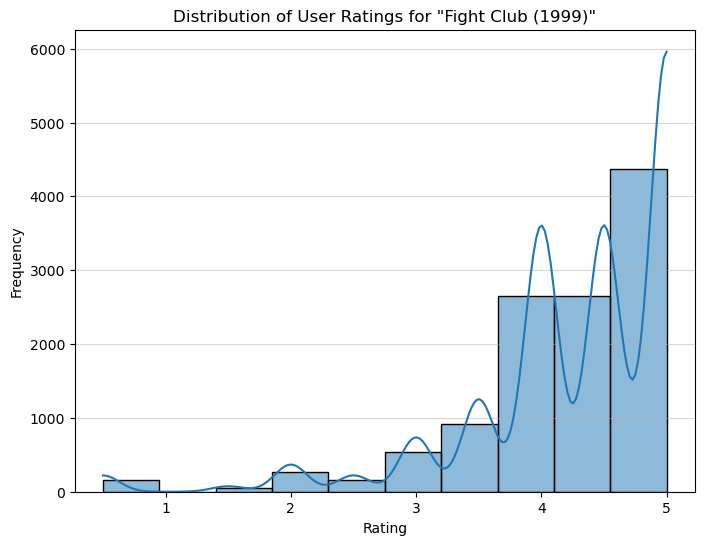

In [117]:
fight_club_ratings = merged_data1[merged_data1['title'] == 'Fight Club (1999)']
ratings = fight_club_ratings['rating']

plt.figure(figsize=(8, 6))
sns.histplot(ratings, bins=10, kde = True, edgecolor='black')
plt.title('Distribution of User Ratings for "Fight Club (1999)"')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [121]:
data = data2.groupby('movieId').agg({'rating': ['count', 'mean']}).reset_index()
data.columns = ['movieId', 'rating_count', 'rating_mean']

x = pd.merge(data1, data, on='movieId', how='inner')
y = x[x['rating_count'] > 50]
y

,movieId,title,genres,rating_count,rating_mean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,110,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,52,3.259615
5,6,Heat (1995),Action|Crime|Thriller,102,3.946078
6,7,Sabrina (1995),Comedy|Romance,54,3.185185
...,...,...,...,...,...
8287,106782,"Wolf of Wall Street, The (2013)",Comedy|Crime|Drama,54,3.916667
8354,109374,"Grand Budapest Hotel, The (2014)",Comedy|Drama,52,3.778846
8358,109487,Interstellar (2014),Sci-Fi|IMAX,73,3.993151
8457,112852,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,59,4.050847


### Which movie is the most popular based on  average user ratings?

In [123]:
y[y['rating_mean'] == y['rating_mean'].max()]['title'].values[0]

'Shawshank Redemption, The (1994)'

### Select all the correct options which comes under top 5 popular movies based on number of user ratings.

In [125]:
y.sort_values(by='rating_count', ascending=False).head(5)

,movieId,title,genres,rating_count,rating_mean
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290
1938,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446


### Which Sci-Fi movie is "third most popular" based on the number of user ratings?

In [137]:
y[y["genres"].str.contains('Sci-Fi')].sort_values(by='rating_count', ascending=False).iloc[2]['title']

'Jurassic Park (1993)'

In [143]:
merged_data2 = pd.merge(data1, data4, on = 'movieId')
merged_data2.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0


### Mention the movieId of the movie which has the highest IMDB rating.


In [159]:
 merged_data2.loc[merged_data2['imdbId'].idxmax(), 'movieId']

193587

### Mention the movieId of the "Sci-Fi" movie which has the highest IMDB rating.

In [153]:
z = merged_data2[merged_data2['genres'].str.contains('Sci-Fi', case=False)]
high_sci_fi = z['imdbId'].max()

z.loc[z['imdbId'] == high_sci_fi, 'movieId'].values[0]

179053